In [ ]:
import os
import clip
import torch
import torch.nn as nn
import numpy as np
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
from pycocotools.coco import COCO
from PIL import Image

print("using {} device.".format(device))
clip_model, img_preprocess = clip.load("ViT-B/32", device = device)
clip_model = clip_model.float()
    
class CombinedModel(nn.Module):
    def __init__(self, clip_model):
        super(CombinedModel, self).__init__()
        self.clip_model = clip_model
        self.visual_projector = nn.Sequential(
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512)
        )
        self.text_projector = nn.Sequential(
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512)
        )

    def forward(self, img_input, text_input):
        img_feats = self.clip_model.encode_image(img_input)
        img_feats = self.visual_projector(img_feats)
        text_feats = self.clip_model.encode_text(text_input)
        text_feats = self.text_projector(text_feats)
        return img_feats, text_feats

# 组合CLIP和自定义网络
combined_model = CombinedModel(clip_model).to(device)
param_dict = torch.load("/home/bd/data/zs/FedMMDP/saved/projector_weights/RMG_projector_MLP.pth")
combined_model.visual_projector.load_state_dict(param_dict['visual_projector'].state_dict())
combined_model.text_projector.load_state_dict(param_dict['text_projector'].state_dict())
combined_model.eval()

cuda
using cuda device.


CombinedModel(
  (clip_model): CLIP(
    (visual): VisionTransformer(
      (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
      (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (transformer): Transformer(
        (resblocks): Sequential(
          (0): ResidualAttentionBlock(
            (attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
            )
            (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (mlp): Sequential(
              (c_fc): Linear(in_features=768, out_features=3072, bias=True)
              (gelu): QuickGELU()
              (c_proj): Linear(in_features=3072, out_features=768, bias=True)
            )
            (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          )
          (1): ResidualAttentionBlock(
            (attn): MultiheadAttention(
              (out_proj): NonDynamicallyQua

In [2]:
np.random.seed(0)
train_instances_info = "/home/bd/data/zs/data/COCO/annotations/instances_train2017.json"
train_captions_info = "/home/bd/data/zs/data/COCO/annotations/captions_train2017.json"
train_image = "/home/bd/data/zs/data/COCO/train2017"

# 加载COCO数据集
coco_captions = COCO(train_captions_info)
train_ids = list(coco_captions.imgs)
random_index=np.random.choice(range(len(train_ids)), size=5000, replace=False)
subset_ids=np.array(train_ids)[random_index]

loading annotations into memory...
Done (t=0.75s)
creating index...
index created!


In [3]:
# 预处理图像
images = []
for i in range(len(subset_ids)):
    img_info = coco_captions.loadImgs(subset_ids)[i]
    img_path = os.path.join('/home/bd/data/zs/data/COCO', 'train2017', img_info['file_name'])
    image = img_preprocess(Image.open(img_path)).unsqueeze(0).to(device)
    images.append(image)
    
captions = [coco_captions.loadAnns(coco_captions.getAnnIds(img_id))[0]['caption'] for img_id in subset_ids]

with torch.no_grad():
    # 初始化用于存储特征的列表
    image_features_list = []
    text_features_list = []
    
    # 批量处理以提高效率
    batch_size = 32
    for i in range(0, len(images), batch_size):
        end = min(i + batch_size, len(images))
        
        # 准备当前批次的图像数据
        batch_imgs = torch.cat(images[i:end])
        
        # 准备当前批次的文本数据
        batch_text = clip.tokenize(captions[i:end]).to(device)
        
        # 使用combined_model处理图像和文本
        img_feats, txt_feats = combined_model(batch_imgs, batch_text)
        
        # 归一化特征
        img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)
        txt_feats = txt_feats / txt_feats.norm(dim=-1, keepdim=True)
        
        # 保存特征
        image_features_list.append(img_feats.cpu().numpy())
        text_features_list.append(txt_feats.cpu().numpy())
    
    # 合并所有批次的特征
    image_features = np.concatenate(image_features_list, axis=0)
    text_features = np.concatenate(text_features_list, axis=0)

# np.save('./img_emb_0.npy', image_features)
# np.save('./txt_emb_0.npy', text_features)

/tmp/ipykernel_1430112/1270349706.py:27: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(image_tsne[:, 0], image_tsne[:, 1], c=sns.color_palette("hls")[0], label='Image Features', alpha=0.5, s=10)
/tmp/ipykernel_1430112/1270349706.py:30: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(text_tsne[:, 0], text_tsne[:, 1],c=sns.color_palette("hls")[1], label='Text Features', alpha=0.5, s=10)


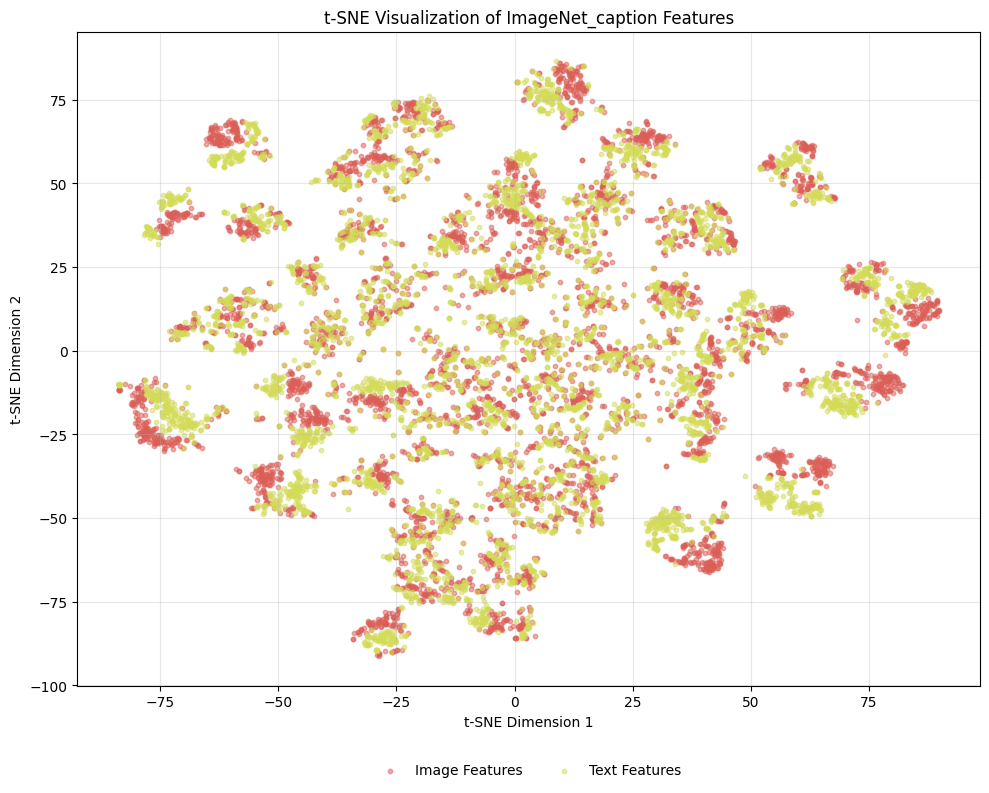

In [5]:
# 假设image_features和text_features是已经加载好的特征数据
# image_features和text_features的形状应该是 (num_samples, feature_dim)

# image_features = np.load('./img_emb_0.npy')
# text_features = np.load('./txt_emb_0.npy')
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.manifold import TSNE

sns.color_palette("hls")

# 将image_features和text_features合并为一个数组
combined_feats = np.concatenate((image_features, text_features), axis=0)
# combined_feats = np.concatenate((tmp_img_embeds.cpu(), tmp_txt_embeds.cpu()), axis=0)

# 创建t-SNE模型并拟合数据
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(combined_feats)

# 分离image_features和text_features的t-SNE结果
image_tsne = tsne_results[:image_features.shape[0]]
text_tsne = tsne_results[image_features.shape[0]:]

plt.figure(figsize=(10, 8))  # 调整图表尺寸以符合论文规范

# 绘制图像特征点
plt.scatter(image_tsne[:, 0], image_tsne[:, 1], c=sns.color_palette("hls")[0], label='Image Features', alpha=0.5, s=10)

# 绘制文本特征点
plt.scatter(text_tsne[:, 0], text_tsne[:, 1],c=sns.color_palette("hls")[1], label='Text Features', alpha=0.5, s=10)

# 添加标题和标签
plt.title('t-SNE Visualization of ImageNet_caption Features', fontsize=12)
plt.xlabel('t-SNE Dimension 1', fontsize=10)
plt.ylabel('t-SNE Dimension 2', fontsize=10)

# 添加网格
plt.grid(alpha=0.3)

# 优化图例显示
plt.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)

# 调整布局
plt.tight_layout()

# 保存为高分辨率 PDF
plt.savefig('tsne_visualization.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.savefig('tsne_visualization.png', format='png', dpi=300, bbox_inches='tight')

# 显示图表
plt.show()

Running FINCH clustering...
Partition 0: 1945 clusters
Partition 1: 433 clusters
Partition 2: 110 clusters
Partition 3: 40 clusters
Partition 4: 21 clusters
Partition 5: 19 clusters
Partition 6: 18 clusters
[[   0    0    0 ...    0    0    0]
 [   1    1    1 ...    1    1    1]
 [   2    2    2 ...    2    2    2]
 ...
 [1839  430   15 ...   10   10   10]
 [ 851  330   12 ...    7    7    7]
 [1496  364   34 ...   17   16   15]]
FINCH found 110 clusters at partition level 2
Performing t-SNE dimensionality reduction...


/tmp/ipykernel_1299384/3404303908.py:68: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


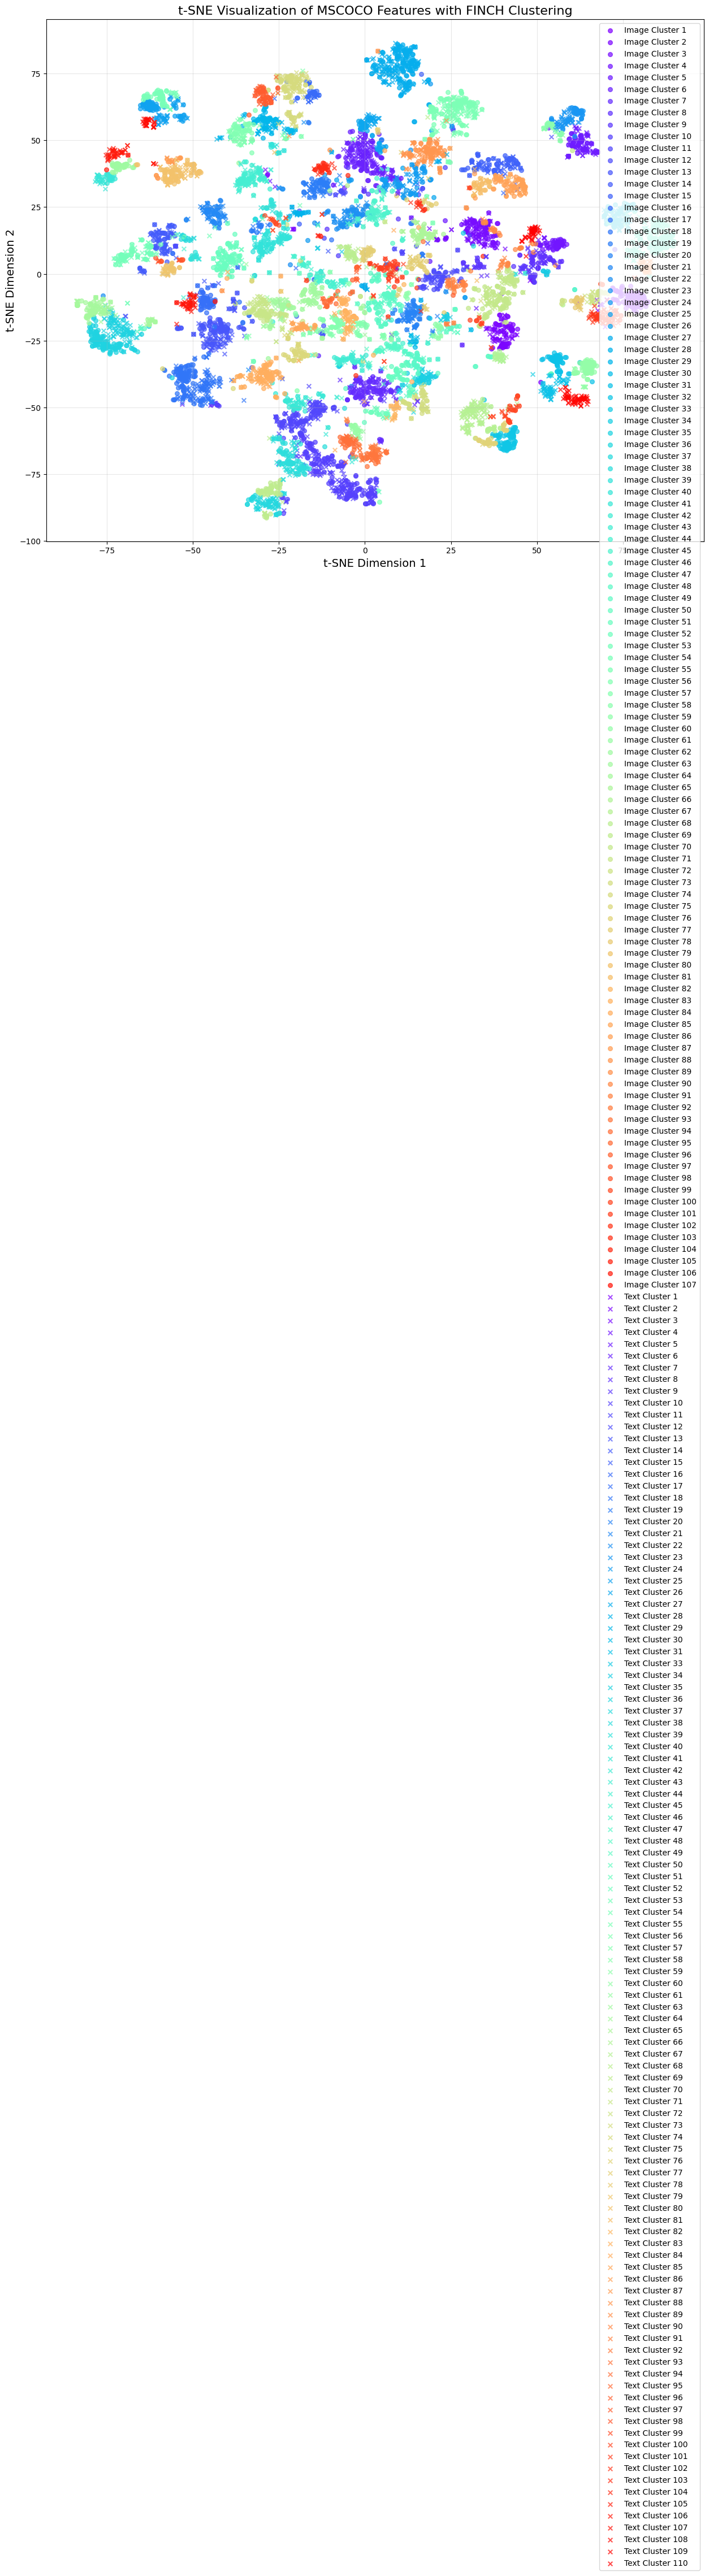

Cluster 1: 111 image features, 10 text features
Cluster 2: 57 image features, 61 text features
Cluster 3: 72 image features, 88 text features
Cluster 4: 59 image features, 7 text features
Cluster 5: 58 image features, 60 text features
Cluster 6: 113 image features, 104 text features
Cluster 7: 82 image features, 74 text features
Cluster 8: 36 image features, 32 text features
Cluster 9: 34 image features, 35 text features
Cluster 10: 151 image features, 156 text features
Cluster 11: 80 image features, 84 text features
Cluster 12: 55 image features, 56 text features
Cluster 13: 103 image features, 87 text features
Cluster 14: 50 image features, 58 text features
Cluster 15: 63 image features, 65 text features
Cluster 16: 22 image features, 20 text features
Cluster 17: 66 image features, 6 text features
Cluster 18: 115 image features, 123 text features
Cluster 19: 57 image features, 64 text features
Cluster 20: 49 image features, 41 text features
Cluster 21: 46 image features, 47 text feat

In [22]:
from finch import FINCH
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Concatenate image and text features
combined_feats = np.concatenate((image_features, text_features), axis=0)

# Apply FINCH clustering
print("Running FINCH clustering...")
cluster, num_cluster, req_cluster = FINCH(combined_feats)

print(cluster)
# Use the first partition level (change index to use different levels)
partition_level = 2
cluster_labels = cluster[:, partition_level]
n_clusters = len(np.unique(cluster_labels))
print(f"FINCH found {n_clusters} clusters at partition level {partition_level}")

# Separate image and text cluster labels
image_labels = cluster_labels[:image_features.shape[0]]
text_labels = cluster_labels[image_features.shape[0]:]

# Apply t-SNE for dimensionality reduction
print("Performing t-SNE dimensionality reduction...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results = tsne.fit_transform(combined_feats)

# Split the results for image and text features
image_tsne = tsne_results[:image_features.shape[0]]
text_tsne = tsne_results[image_features.shape[0]:]

# Create a colormap for clusters
colors = plt.cm.rainbow(np.linspace(0, 1, n_clusters))

# Create visualization
plt.figure(figsize=(15, 12))

# Plot image features with cluster colors
for i in range(n_clusters):
    idx = np.where(image_labels == i)[0]
    if len(idx) > 0:
        plt.scatter(image_tsne[idx, 0], image_tsne[idx, 1], 
                   color=colors[i], marker='o', 
                   label=f'Image Cluster {i+1}',
                   alpha=0.7, s=30)

# Plot text features with cluster colors
for i in range(n_clusters):
    idx = np.where(text_labels == i)[0]
    if len(idx) > 0:
        plt.scatter(text_tsne[idx, 0], text_tsne[idx, 1], 
                   color=colors[i], marker='x', 
                   label=f'Text Cluster {i+1}',
                   alpha=0.7, s=30)

# Add labels and title
plt.title('t-SNE Visualization of MSCOCO Features with FINCH Clustering', fontsize=16)
plt.xlabel('t-SNE Dimension 1', fontsize=14)
plt.ylabel('t-SNE Dimension 2', fontsize=14)

# Optimize legend display (show each cluster once)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=10)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics for each cluster
for i in range(n_clusters):
    img_count = np.sum(image_labels == i)
    txt_count = np.sum(text_labels == i)
    print(f"Cluster {i+1}: {img_count} image features, {txt_count} text features")

正在对特征向量进行同态加密...
计算原始数据的余弦相似度矩阵...
计算加密数据的余弦相似度矩阵...
总计算耗时: 0.37 秒
同态加密前后余弦相似度最大差异: 0.0000005983
同态加密前后余弦相似度平均差异: 0.0000000155


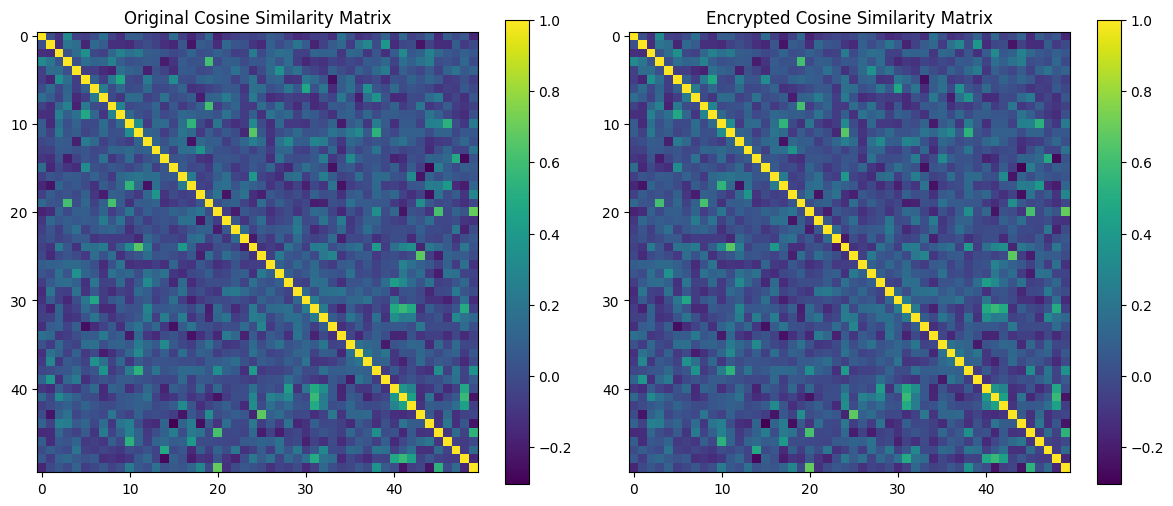

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import time

def homomorphic_encryption(features, seed=42):
    
    np.random.seed(seed)
    
    # 获取特征维度
    n_features = features.shape[1]
    
    # 生成随机矩阵
    random_matrix = np.random.randn(n_features, n_features)
    
    # 使用QR分解获得正交矩阵 (旋转矩阵)
    q, r = np.linalg.qr(random_matrix)
    
    # 应用旋转变换 (矩阵乘法)
    encrypted_features = np.dot(features, q)
    
    return encrypted_features, q

# 开始计时
start_time = time.time()

# 对图像和文本特征进行加密
print("正在对特征向量进行同态加密...")
encrypted_features, encryption_matrix = homomorphic_encryption(combined_feats)

# 计算原始特征的余弦相似度矩阵
print("计算原始数据的余弦相似度矩阵...")
original_similarity = cosine_similarity(combined_feats)

# 计算加密后特征的余弦相似度矩阵
print("计算加密数据的余弦相似度矩阵...")
encrypted_similarity = cosine_similarity(encrypted_features)

# 结束计时
elapsed_time = time.time() - start_time
print(f"总计算耗时: {elapsed_time:.2f} 秒")

# 验证两个相似度矩阵的差异
diff = np.abs(original_similarity - encrypted_similarity).max()
mean_diff = np.abs(original_similarity - encrypted_similarity).mean()
print(f"同态加密前后余弦相似度最大差异: {diff:.10f}")
print(f"同态加密前后余弦相似度平均差异: {mean_diff:.10f}")

# 可视化相似度矩阵比较
plt.figure(figsize=(12, 5))

# Select a portion of the data for visualization
n_show = 50
plt.subplot(1, 2, 1)
plt.imshow(original_similarity[:n_show, :n_show], cmap='viridis')
plt.colorbar()
plt.title('Original Cosine Similarity Matrix')

plt.subplot(1, 2, 2)
plt.imshow(encrypted_similarity[:n_show, :n_show], cmap='viridis')
plt.colorbar()
plt.title('Encrypted Cosine Similarity Matrix')

plt.tight_layout()
plt.show()

# 保存加密后的特征（可选）
# np.save('encrypted_img_features.npy', encrypted_image_features)
# np.save('encrypted_txt_features.npy', encrypted_text_features)

计算余弦相似度矩阵...
进行谱聚类...


执行t-SNE降维...


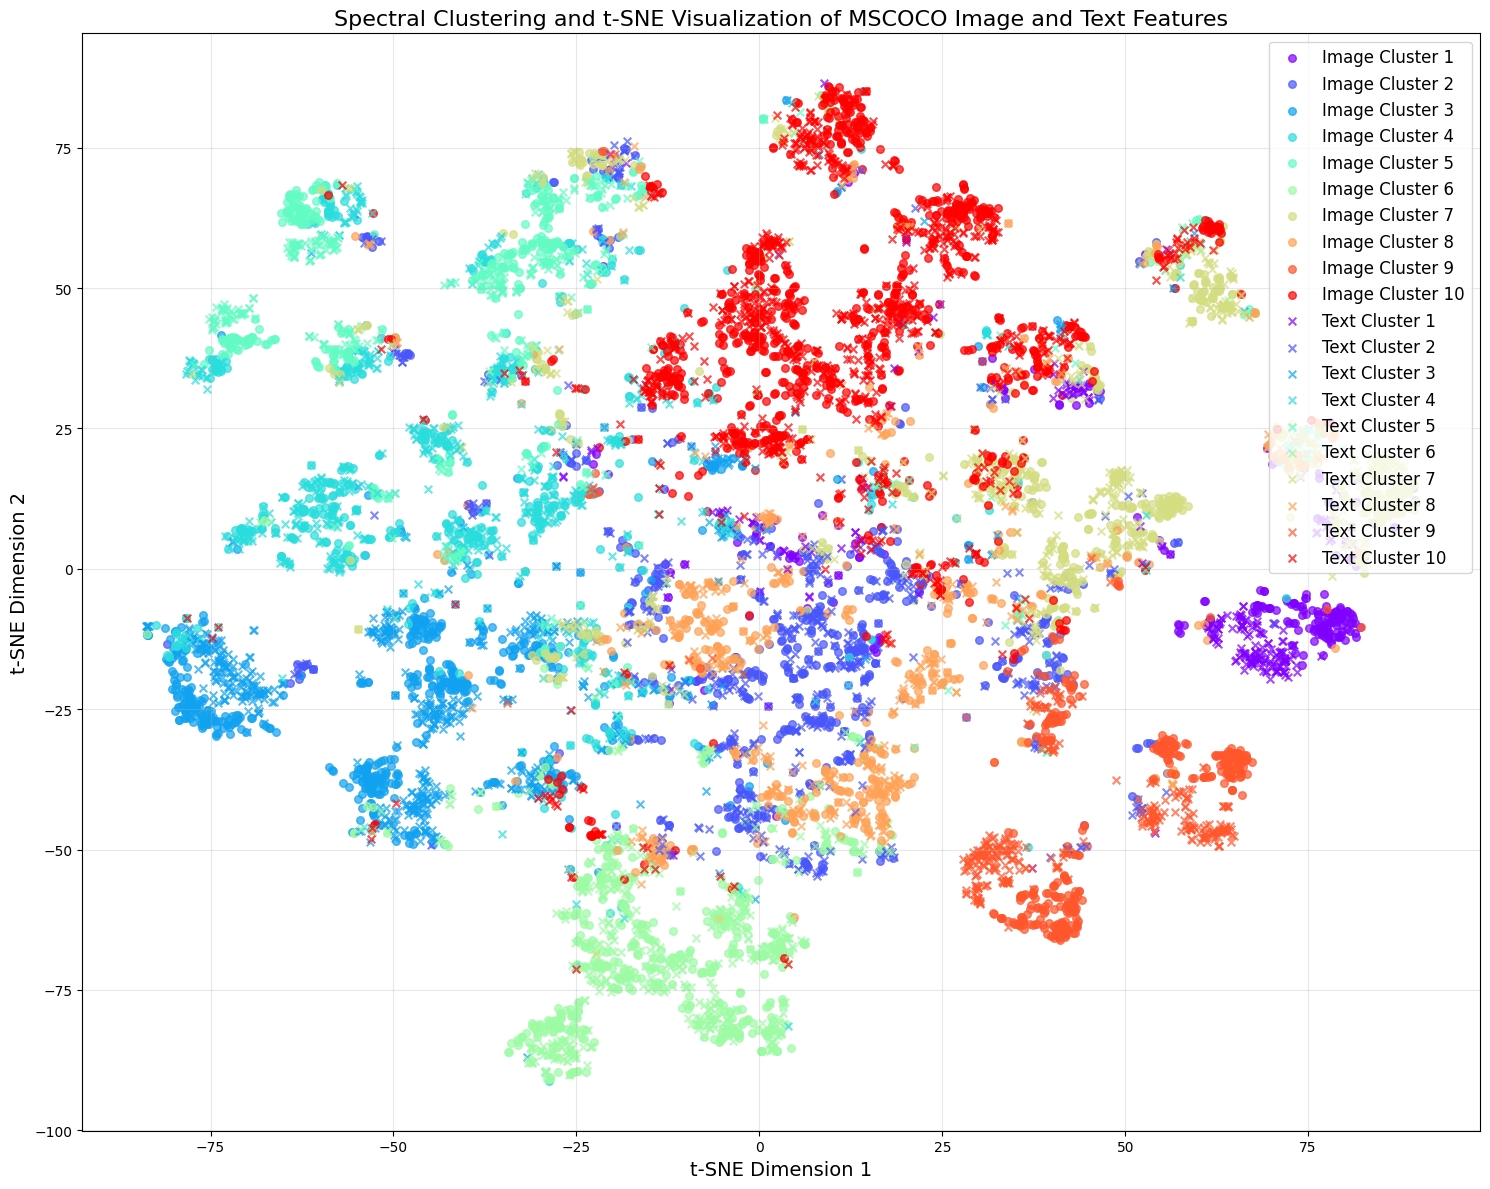

Cluster 1: Contains 250 image features, 282 text features
Cluster 2: Contains 497 image features, 556 text features
Cluster 3: Contains 562 image features, 615 text features
Cluster 4: Contains 605 image features, 554 text features
Cluster 5: Contains 357 image features, 418 text features
Cluster 6: Contains 497 image features, 518 text features
Cluster 7: Contains 554 image features, 559 text features
Cluster 8: Contains 442 image features, 362 text features
Cluster 9: Contains 358 image features, 346 text features
Cluster 10: Contains 878 image features, 790 text features


In [24]:
# 计算余弦相似度矩阵并转换为距离矩阵
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import SpectralClustering
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

# 计算余弦相似度矩阵
print("计算余弦相似度矩阵...")
similarity_matrix = encrypted_similarity + 1

# 进行谱聚类
print("进行谱聚类...")
n_clusters = 10  # 可以根据需要调整聚类数量
spectral = SpectralClustering(n_clusters=n_clusters, 
                              affinity='precomputed',
                              random_state=42,
                              assign_labels='kmeans')

# 使用相似度矩阵而非距离矩阵作为亲和度矩阵
cluster_labels = spectral.fit_predict(similarity_matrix)

# 使用t-SNE进行降维可视化
print("执行t-SNE降维...")
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(combined_feats)

# 分离image_features和text_features的t-SNE结果
image_tsne = tsne_results[:image_features.shape[0]]
text_tsne = tsne_results[image_features.shape[0]:]

# 分离image和text的聚类标签
image_labels = cluster_labels[:image_features.shape[0]]
text_labels = cluster_labels[image_features.shape[0]:]

# Create visualization
plt.figure(figsize=(15, 12))

# Create color mapping
colors = plt.cm.rainbow(np.linspace(0, 1, n_clusters))

# Plot image feature points, colored by cluster
for i in range(n_clusters):
    plt.scatter(image_tsne[image_labels == i, 0], 
                image_tsne[image_labels == i, 1],
                color=colors[i], 
                marker='o',
                label=f'Image Cluster {i+1}',
                alpha=0.7, 
                s=30)

# Plot text feature points, colored by cluster and using different markers
for i in range(n_clusters):
    plt.scatter(text_tsne[text_labels == i, 0], 
                text_tsne[text_labels == i, 1],
                color=colors[i], 
                marker='x',
                label=f'Text Cluster {i+1}',
                alpha=0.7, 
                s=30)

# Add title and legend
plt.title('Spectral Clustering and t-SNE Visualization of MSCOCO Image and Text Features', fontsize=16)
plt.xlabel('t-SNE Dimension 1', fontsize=14)
plt.ylabel('t-SNE Dimension 2', fontsize=14)

# Optimize legend display (show each cluster only once)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics for each cluster
for i in range(n_clusters):
    img_count = np.sum(image_labels == i)
    txt_count = np.sum(text_labels == i)
    print(f"Cluster {i+1}: Contains {img_count} image features, {txt_count} text features")

In [6]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def calculate_accuracy(image_features, text_features, labels, threshold=0.5):
    # 计算余弦相似度矩阵
    similarity_matrix = cosine_similarity(image_features, text_features)
    
    # 根据阈值判断匹配情况
    predictions = (similarity_matrix > threshold).astype(int)
    
    # 计算准确率
    accuracy = np.mean(predictions == labels)
    
    return accuracy

# 假设image_features和text_features是已经加载好的特征数据
# image_features和text_features的形状应该是 (num_samples, feature_dim)
# labels是一个二维数组，形状为 (num_samples, num_samples)，表示正确的匹配情况（1表示匹配，0表示不匹配）

# 示例数据
num_samples = 5000
feature_dim = 512
labels = np.eye(num_samples)  # 假设每个图像只与一个文本匹配

# 计算准确率
accuracy = calculate_accuracy(image_features, text_features, labels)
print(f"图文匹配准确率: {accuracy * 100:.2f}%")

图文匹配准确率: 99.31%


In [7]:
# Import the necessary modules for Flickr30k dataset
import os
import pickle
from torch.utils.data import Dataset, DataLoader, Subset
import torch.nn.functional as F
from tqdm import tqdm

class F30kCaptionsCap(Dataset):
    def __init__(self, annFile='dataset_k_split.pkl', split='train',
                 transform=None, target_transform=None):
        self.transform = transform
        self.target_transform = target_transform
        self.data = pickle.load(open(annFile, 'rb'))
        if split not in self.data.keys():
            assert False, f'split wrong {split}'
        self.data = self.data[split]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        data = self.data[index]
        caption = data[1]

        path = data[0].replace('/data/mmdata/Flick30k/flickr30k-images/',
                       '/home/bd/data/zs/data/flickr30k/flickr30k-images/')

        img = Image.open(path).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)

        if self.target_transform is not None:
            target = self.target_transform(caption)[0]
            return img, target, caption
        return img, caption


FLICKR_PATH = 'dataset_k_split.pkl'
flickr30k_dataset = F30kCaptionsCap(FLICKR_PATH, transform=img_preprocess,
                                    target_transform=clip.tokenize)
print(f"Loaded Flickr30k dataset with {len(flickr30k_dataset)} samples")

# Sample a subset of the dataset if it's large
sample_size = min(2000, len(flickr30k_dataset) if 'flickr30k_dataset' in locals() else 0)
if sample_size > 0:
    indices = np.random.choice(len(flickr30k_dataset), sample_size, replace=False)
    flickr30k_subset = Subset(flickr30k_dataset, indices)
    
    # Create a DataLoader for efficient batching
    batch_size = 32
    dataloader = DataLoader(flickr30k_subset, batch_size=batch_size, shuffle=False)

    # Process the dataset to extract image and text features
    image_features_list = []
    text_features_list = []
    
    combined_model.eval()  # Ensure the model is in evaluation mode
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Processing Flickr30k"):
            images, text_tokens, captions = batch
            
            # Move data to device
            images = images.to(device)
            text_tokens = text_tokens.to(device)
            
            # Get features
            img_feats, txt_feats = combined_model(images, text_tokens)
            
            # Normalize features
            img_feats = F.normalize(img_feats, p=2, dim=1)
            txt_feats = F.normalize(txt_feats, p=2, dim=1)
            
            # Store features
            image_features_list.append(img_feats.cpu().numpy())
            text_features_list.append(txt_feats.cpu().numpy())
            
    # Concatenate all batches
    flickr_img_features = np.concatenate(image_features_list, axis=0)
    flickr_txt_features = np.concatenate(text_features_list, axis=0)
    
    print(f"Generated features for {flickr_img_features.shape[0]} Flickr30k images and texts")

Loaded Flickr30k dataset with 145000 samples


Processing Flickr30k:   3%|▎         | 2/63 [00:00<00:17,  3.49it/s]

Processing Flickr30k: 100%|██████████| 63/63 [00:16<00:00,  3.78it/s]

Generated features for 2000 Flickr30k images and texts


/mnt/data/software/anaconda/envs/zs_vita/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Performing t-SNE dimensionality reduction...


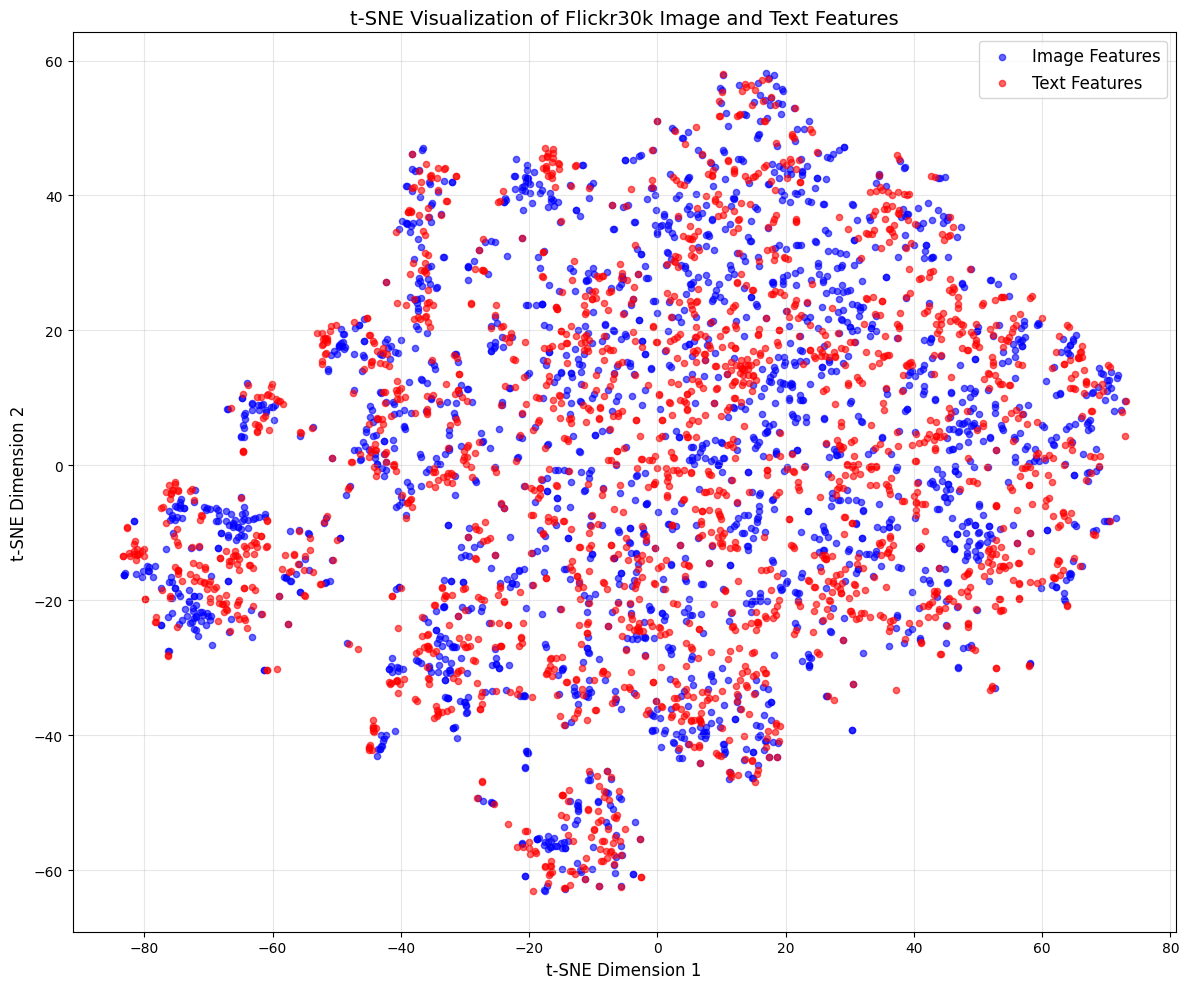

In [8]:
# Visualize Flickr30k image and text features using t-SNE
from matplotlib import pyplot as plt
from sklearn.manifold import TSNE

# Combine image and text features
flickr_combined_feats = np.concatenate((flickr_img_features, flickr_txt_features), axis=0)

# Apply t-SNE dimensionality reduction
print("Performing t-SNE dimensionality reduction...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
flickr_tsne_results = tsne.fit_transform(flickr_combined_feats)

# Split the results back into image and text features
flickr_img_tsne = flickr_tsne_results[:flickr_img_features.shape[0]]
flickr_txt_tsne = flickr_tsne_results[flickr_img_features.shape[0]:]

# Create visualization
plt.figure(figsize=(12, 10))

# Plot image and text embeddings
plt.scatter(flickr_img_tsne[:, 0], flickr_img_tsne[:, 1], c='blue', label='Image Features', alpha=0.6, s=20)
plt.scatter(flickr_txt_tsne[:, 0], flickr_txt_tsne[:, 1], c='red', label='Text Features', alpha=0.6, s=20)

# Add title and legend
plt.title('t-SNE Visualization of Flickr30k Image and Text Features', fontsize=14)
plt.legend(fontsize=12)

# Add axis labels
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)

# Add grid for better readability
plt.grid(alpha=0.3)

# Improve layout
plt.tight_layout()

# Save the visualization
# os.makedirs('visualization_results', exist_ok=True)
# plt.savefig('visualization_results/flickr30k_tsne_visualization.png', dpi=300, bbox_inches='tight')
# print("Visualization saved to 'visualization_results/flickr30k_tsne_visualization.png'")

plt.show()

In [9]:
# Calculate alignment metrics between image and text features
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def calculate_retrieval_metrics(img_features, txt_features):
    """Calculate image-to-text and text-to-image retrieval metrics"""
    # Calculate cosine similarity between all images and texts
    similarity_matrix = cosine_similarity(img_features, txt_features)
    
    # For each image, find the rank of its corresponding text
    i2t_ranks = []
    for i in range(len(img_features)):
        # Get the similarity scores for this image with all texts
        similarities = similarity_matrix[i, :]
        # The ground truth match should be at the same index
        target_similarity = similarities[i]
        # Count how many texts are more similar to this image than the ground truth
        rank = np.sum(similarities > target_similarity) + 1
        i2t_ranks.append(rank)
    
    # For each text, find the rank of its corresponding image
    t2i_ranks = []
    for i in range(len(txt_features)):
        # Get the similarity scores for this text with all images
        similarities = similarity_matrix[:, i]
        # The ground truth match should be at the same index
        target_similarity = similarities[i]
        # Count how many images are more similar to this text than the ground truth
        rank = np.sum(similarities > target_similarity) + 1
        t2i_ranks.append(rank)
    
    # Calculate metrics
    i2t_ranks = np.array(i2t_ranks)
    t2i_ranks = np.array(t2i_ranks)
    
    # Recall@K metrics
    metrics = {
        'i2t_r1': np.mean(i2t_ranks <= 1) * 100,
        'i2t_r5': np.mean(i2t_ranks <= 5) * 100,
        'i2t_r10': np.mean(i2t_ranks <= 10) * 100,
        't2i_r1': np.mean(t2i_ranks <= 1) * 100,
        't2i_r5': np.mean(t2i_ranks <= 5) * 100,
        't2i_r10': np.mean(t2i_ranks <= 10) * 100,
        'i2t_median_rank': np.median(i2t_ranks),
        't2i_median_rank': np.median(t2i_ranks)
    }
    
    return metrics

# Calculate and print metrics
metrics = calculate_retrieval_metrics(flickr_img_features, flickr_txt_features)

print("Flickr30k Retrieval Performance:")
print(f"Image-to-Text:")
print(f"  Recall@1: {metrics['i2t_r1']:.2f}%")
print(f"  Recall@5: {metrics['i2t_r5']:.2f}%")
print(f"  Recall@10: {metrics['i2t_r10']:.2f}%")
print(f"  Median Rank: {metrics['i2t_median_rank']}")
print(f"Text-to-Image:")
print(f"  Recall@1: {metrics['t2i_r1']:.2f}%")
print(f"  Recall@5: {metrics['t2i_r5']:.2f}%")
print(f"  Recall@10: {metrics['t2i_r10']:.2f}%")
print(f"  Median Rank: {metrics['t2i_median_rank']}")

Flickr30k Retrieval Performance:
Image-to-Text:
  Recall@1: 39.80%
  Recall@5: 70.70%
  Recall@10: 79.75%
  Median Rank: 2.0
Text-to-Image:
  Recall@1: 41.40%
  Recall@5: 71.00%
  Recall@10: 80.35%
  Median Rank: 2.0


In [10]:
# Process the dataset to extract image and text features
original_image_features_list = []
original_text_features_list = []

combined_model.eval()  # Ensure the model is in evaluation mode

with torch.no_grad():
    for batch in tqdm(dataloader, desc="Processing Flickr30k"):
        images, text_tokens, captions = batch
        
        # Move data to device
        images = images.to(device)
        text_tokens = text_tokens.to(device)
        
        # Get features
        img_feats = clip_model.encode_image(images)
        txt_feats = clip_model.encode_text(text_tokens)
        
        # Normalize features
        img_feats = F.normalize(img_feats, p=2, dim=1)
        txt_feats = F.normalize(txt_feats, p=2, dim=1)
        
        # Store features
        original_image_features_list.append(img_feats.cpu().numpy())
        original_text_features_list.append(txt_feats.cpu().numpy())
        
# Concatenate all batches
original_flickr_img_features = np.concatenate(original_image_features_list, axis=0)
original_flickr_txt_features = np.concatenate(original_text_features_list, axis=0)

original_metrics = calculate_retrieval_metrics(original_flickr_img_features, original_flickr_txt_features)
print("Flickr30k Retrieval Performance:")
print(f"Image-to-Text:")
print(f"  Recall@1: {original_metrics['i2t_r1']:.2f}%")
print(f"  Recall@5: {original_metrics['i2t_r5']:.2f}%")
print(f"  Recall@10: {original_metrics['i2t_r10']:.2f}%")
print(f"  Median Rank: {original_metrics['i2t_median_rank']}")
print(f"Text-to-Image:")
print(f"  Recall@1: {original_metrics['t2i_r1']:.2f}%")
print(f"  Recall@5: {original_metrics['t2i_r5']:.2f}%")
print(f"  Recall@10: {original_metrics['t2i_r10']:.2f}%")
print(f"  Median Rank: {original_metrics['t2i_median_rank']}")

Processing Flickr30k: 100%|██████████| 63/63 [00:17<00:00,  3.66it/s]

Flickr30k Retrieval Performance:
Image-to-Text:
  Recall@1: 51.75%
  Recall@5: 79.35%
  Recall@10: 87.30%
  Median Rank: 1.0
Text-to-Image:
  Recall@1: 49.00%
  Recall@5: 77.00%
  Recall@10: 84.70%
  Median Rank: 2.0


In [2]:
import os
import pickle
# Reload the dataset from local files
dataset_list = []
for file in os.listdir("/home/bd/data/zs/FedMMDP/data/full_dataset/dataset1"):
    if file.endswith(".pkl"):
        dataset_path = os.path.join("/home/bd/data/zs/FedMMDP/data/full_dataset/dataset1", file)
        print(f"Loading dataset from {dataset_path}")
        with open(dataset_path, "rb") as f:
            imgcap_dataset = pickle.load(f)
            dataset_list.append(imgcap_dataset)

print("Dataset reloaded from local files.")

Loading dataset from /home/bd/data/zs/FedMMDP/data/full_dataset/dataset1/imgcap_dataset0.pkl
Loading dataset from /home/bd/data/zs/FedMMDP/data/full_dataset/dataset1/imgcap_dataset1.pkl
Loading dataset from /home/bd/data/zs/FedMMDP/data/full_dataset/dataset1/imgcap_dataset2.pkl
Loading dataset from /home/bd/data/zs/FedMMDP/data/full_dataset/dataset1/imgcap_dataset3.pkl
Loading dataset from /home/bd/data/zs/FedMMDP/data/full_dataset/dataset1/imgcap_dataset4.pkl
Loading dataset from /home/bd/data/zs/FedMMDP/data/full_dataset/dataset1/imgcap_dataset5.pkl
Dataset reloaded from local files.


In [3]:
from datasets import Dataset, concatenate_datasets
for i in range(len(dataset_list)):
    dataset_list[i] = Dataset.from_list(dataset_list[i])
full_dataset = concatenate_datasets(dataset_list)
print(full_dataset)

Dataset({
    features: ['class', 'id', 'recaption_short', 'cap_tokens', 'processed_img'],
    num_rows: 10146
})


In [4]:
from collections import Counter
class_counts = Counter(sample["class"] for sample in full_dataset)

popular_classes = {cls: count for cls, count in class_counts.items() if count >= 100}
dataset = full_dataset.filter(lambda x: x["class"] in popular_classes)
print(f"Filtered dataset size: {len(dataset)}")

print("Class:{}, Count:{}".format(popular_classes.keys(), popular_classes.values()))

print("Class_size:{}".format(len(popular_classes)))

Filter: 100%|██████████| 10146/10146 [07:45<00:00, 21.81 examples/s]

Filtered dataset size: 10137
Class:dict_keys(['benthos', 'cell', 'person, individual, someone, somebody, mortal, soul', 'animal, animate_being, beast, brute, creature, fauna', 'plant, flora, plant_life', 'food, nutrient', 'artifact, artefact', 'hop', 'check-in']), Count:dict_values([1264, 1251, 1242, 1570, 1271, 1272, 1249, 811, 207])
Class_size:9


In [9]:
full_dataset.to_iterable_dataset()

IterableDataset({
    features: ['class', 'id', 'recaption_short', 'cap_tokens', 'processed_img'],
    num_shards: 1
})

In [ ]:
full_dataset.save_to_disk('data/full_dataset')

Saving the dataset (21/21 shards): 100%|██████████| 16908/16908 [01:24<00:00, 200.46 examples/s]


In [4]:
from datasets import load_from_disk
full_dataset = load_from_disk('data/full_dataset')

In [6]:
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch

def collate_fn(batch):
    """
    自定义批处理函数，确保图像和文本数据被正确转换为张量
    """
    # 将所有样本的图像和文本数据提取出来
    processed_imgs = []
    cap_tokens = []
    other_data = {}
    
    for item in batch:
        # 处理图像数据
        if isinstance(item["processed_img"], torch.Tensor):
            processed_imgs.append(item["processed_img"])
        else:
            processed_imgs.append(torch.tensor(item["processed_img"], dtype=torch.float))
        
        # 处理文本数据
        if isinstance(item["cap_tokens"], torch.Tensor):
            cap_tokens.append(item["cap_tokens"])
        else:
            cap_tokens.append(torch.tensor(item["cap_tokens"], dtype=torch.long))
        
        # 收集其他数据字段
        for k, v in item.items():
            if k not in ["processed_img", "cap_tokens"]:
                if k not in other_data:
                    other_data[k] = []
                other_data[k].append(v)
    
    # 将列表转换为批次张量
    result = {
        "processed_img": torch.stack(processed_imgs),
        "cap_tokens": torch.stack(cap_tokens)
    }
    
    # 添加其他数据字段
    for k, v in other_data.items():
        result[k] = v
    
    return result

dataloader = DataLoader(full_dataset, batch_size=32, collate_fn=collate_fn)
with torch.no_grad():
    images_features_list = []
    texts_features_list = []
    for batch in tqdm(dataloader):
        # Get the image and text data
        images = batch["processed_img"].to(device)
        texts = batch["cap_tokens"].to(device)

        # Encode the images and texts
        image_features, text_features = combined_model(images, texts)

        # Normalize the features
        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)
        
        # Store the features
        images_features_list.append(image_features.cpu().numpy())
        texts_features_list.append(text_features.cpu().numpy())
    
    imgcap_images_features = np.concatenate(images_features_list, axis=0)
    imgcap_texts_features = np.concatenate(texts_features_list, axis=0)

100%|██████████| 529/529 [13:51<00:00,  1.57s/it]


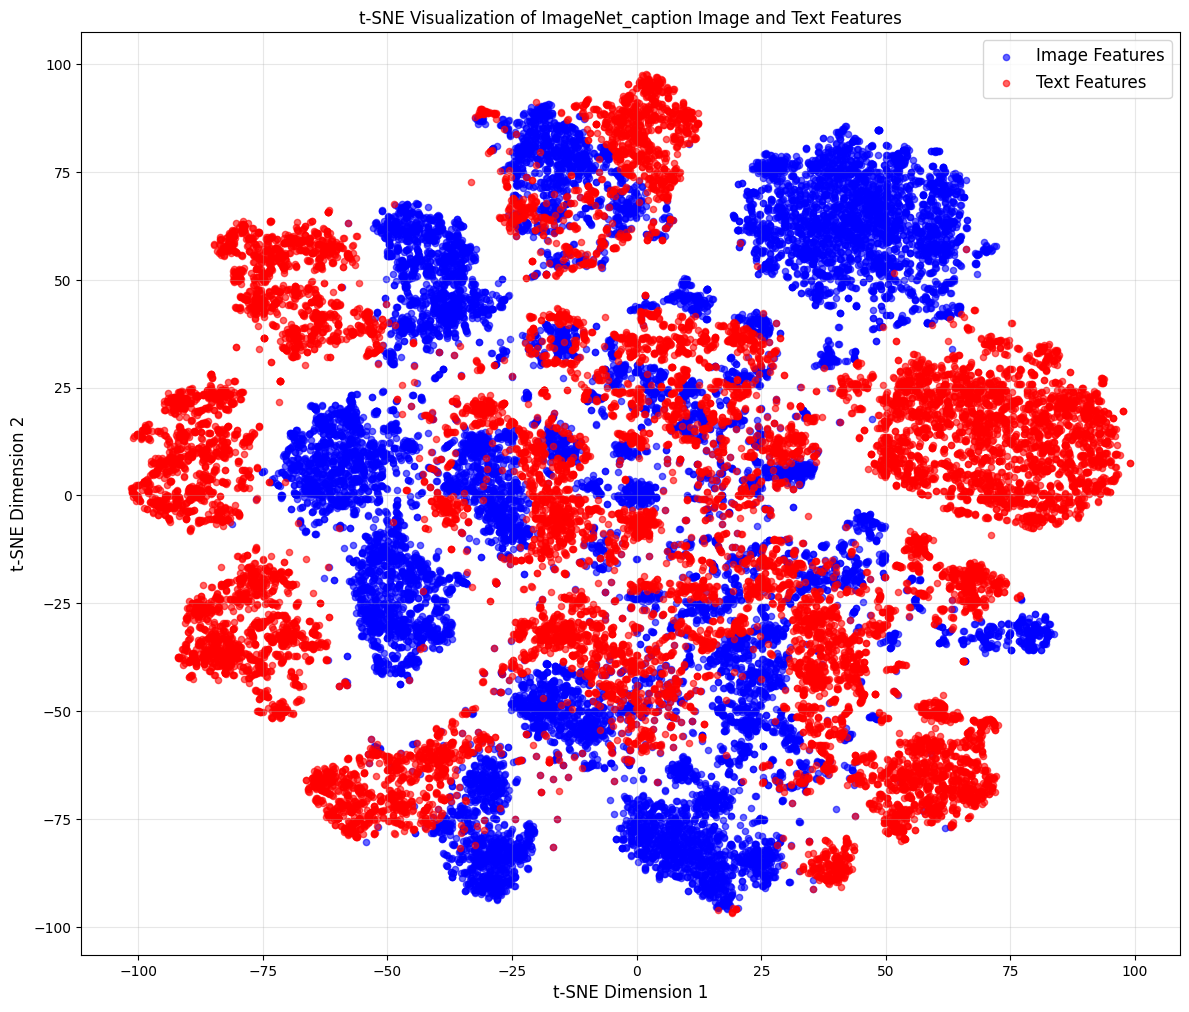

In [7]:
from matplotlib import pyplot as plt
from sklearn.manifold import TSNE

# 将image_features和text_features合并为一个数组
combined_feats = np.concatenate((imgcap_images_features, imgcap_texts_features), axis=0)
# combined_feats = np.concatenate((tmp_img_embeds.cpu(), tmp_txt_embeds.cpu()), axis=0)

# 创建t-SNE模型并拟合数据
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(combined_feats)

# 分离image_features和text_features的t-SNE结果
image_tsne = tsne_results[:imgcap_images_features.shape[0]]
text_tsne = tsne_results[imgcap_images_features.shape[0]:]

# 可视化结果

# Create visualization
plt.figure(figsize=(12, 10))
plt.scatter(image_tsne[:, 0], image_tsne[:, 1], c='blue', label='Image Features', alpha=0.6, s=20)
plt.scatter(text_tsne[:, 0], text_tsne[:, 1], c='red', label='Text Features', alpha=0.6, s=20)
plt.legend()
plt.legend(fontsize=12)

# Add axis labels
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)

# Add grid for better readability
plt.grid(alpha=0.3)

# Improve layout
plt.tight_layout()
plt.title('t-SNE Visualization of ImageNet_caption Image and Text Features')
plt.show()

In [ ]:
from datasets import load_dataset
import torch
import clip
from PIL import Image
import io

tokenizer = clip.tokenize
_, preprocess = clip.load("ViT-B/32", device="cuda")
dataset = load_dataset("gmongaras/Imagenet21K_Recaption", data_dir="/home/bd/data/zs/FedMMDP/dataset/data", split="train", streaming=True)
example = next(iter(dataset))
example["processed_img"] = preprocess(Image.open(io.BytesIO(example["image"]))).cpu().numpy().tolist()
print(example)


{'image': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01\xf4\x00\x00\x01M\x08\x02\x00\x00\x00yq\n`\x00\x00\n1iCCPICC Profile\x00\x00x\x9c\x9d\x96wTS\xd9\x16\x87\xcf\xbd7\xbdP\x92\x10\x8a\x94\xd0khR\x02H\r\xbdH\x91.*1\t\x10J\xc0\x90\x00"6DTpDQ\x91\xa6\x082(\xe0\x80\xa3C\x91\xb1"\x8a\x85\x01Q\xb1\xeb\x04\x19D\xd4qp\x14\x1b\x96Id\xad\x19\xdf\xbcy\xef\xcd\x9b\xdf\x1f\xf7~k\x9f\xbd\xcf\xddg\xef}\xd6\xba\x00\x90\xfc\x83\x05\xc2LX\t\x80\x0c\xa1X\x14\xe1\xe7\xc5\x88\x8d\x8bg`\x07\x01\x0c\xf0\x00\x03l\x00\xe0p\xb3\xb3B\x16\xf8F\x02\x99\x02|\xd8\x8cl\x99\x13\xf8\x17\xbd\xba\x0e \xf9\xfb*\xd3?\x8c\xc1\x00\xff\x9f\x94\xb9Y"1\x00P\x98\x8c\xe7\xf2\xf8\xd9\\\x19\x17\xc98=W\x9c%\xb7O\xc9\x98\xb64M\xce0J\xce"Y\x822V\x93s\xf2,[|\xf6\x99e\x0f9\xf32\x84<\x19\xcbs\xce\xe2e\xf0\xe4\xdc\'\xe3\x8d9\x12\xbe\x8c\x91`\x19\x17\xe7\x08\xf8\xb92\xbe&c\x83tI\x86@\xc6o\xe4\xb1\x19|N6\x00(\x92\xdc.\xe6sSdl-c\x92(2\x82-\xe3y\x00\xe0H\xc9_\xf0\xd2/X\xcc\xcf\x13\xcb\x0f\xc5\xce\xccZ.\x12$\xa7\x88\x19&\\S\x86\x8d\x93\x

In [2]:
from datasets import load_dataset

dataset = load_dataset("gmongaras/Imagenet21K_Recaption", data_dir="/home/bd/data/zs/FedMMDP/dataset/data")

ConnectionError: Couldn't reach 'gmongaras/Imagenet21K_Recaption' on the Hub (LocalEntryNotFoundError)